In [1]:
import cv2
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

In [14]:
full = cv2.imread('../DATA/sammy.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)

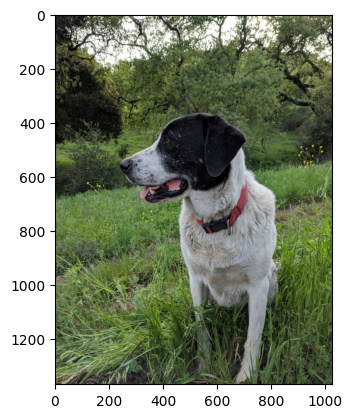

In [15]:
plt.imshow(full)

In [16]:
face = cv2.imread('../DATA/sammy_face.jpg')
face = cv2.cvtColor(face,cv2.COLOR_BGR2RGB)

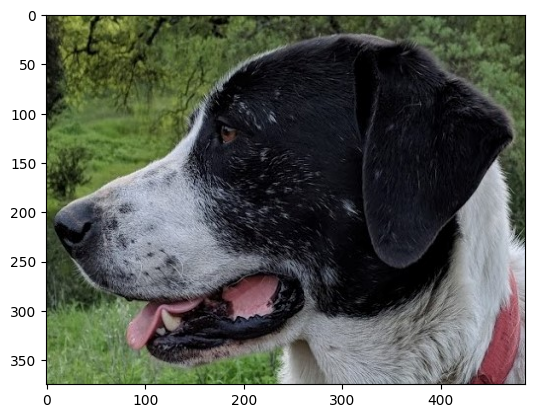

In [17]:
plt.imshow(face)

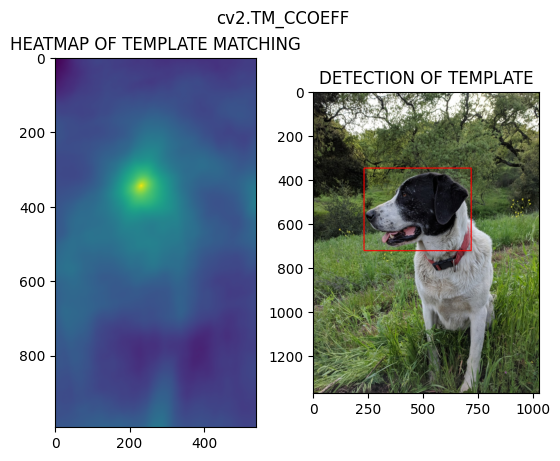

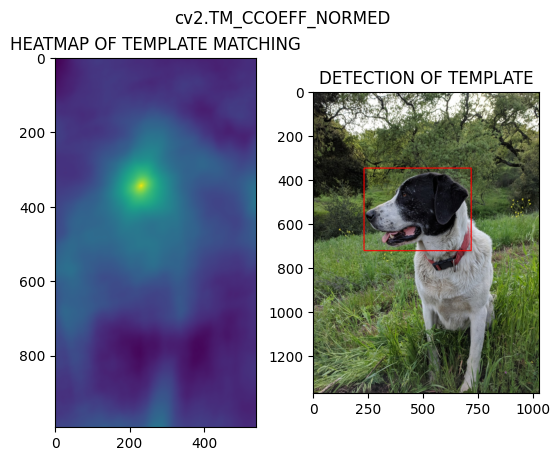

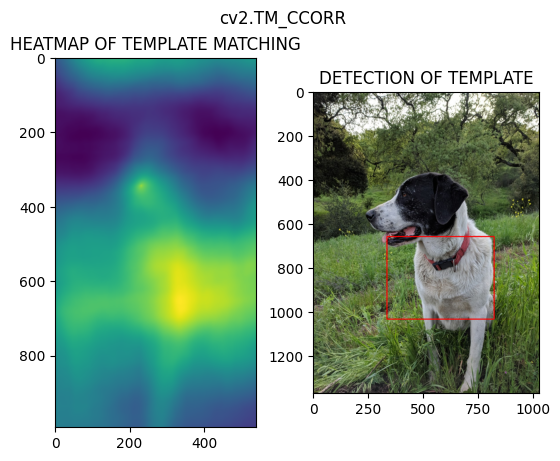

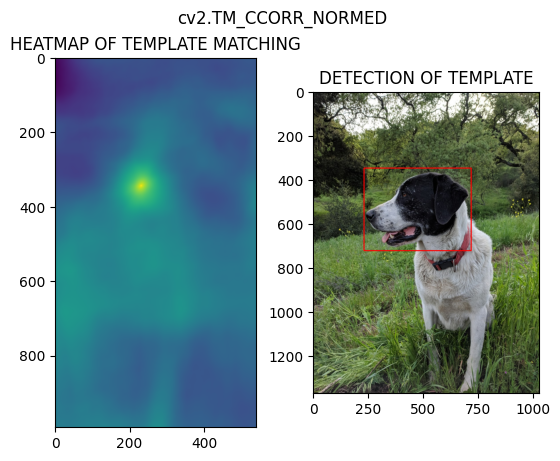

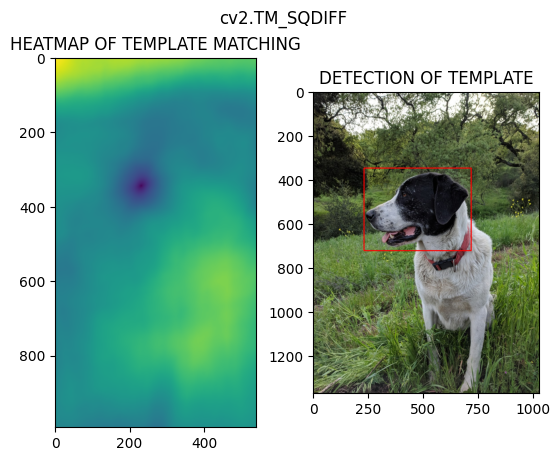

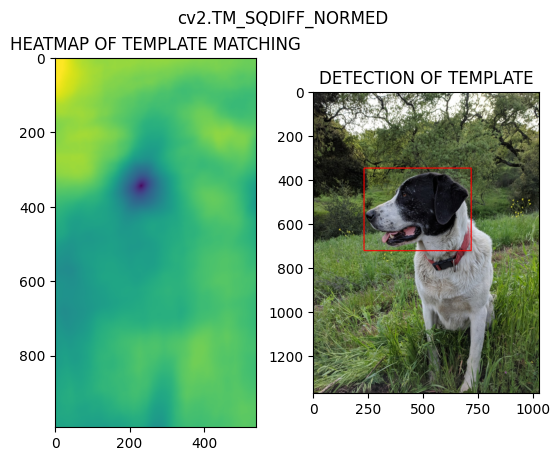

In [34]:
methods = ['cv2.TM_CCOEFF','cv2.TM_CCOEFF_NORMED','cv2.TM_CCORR','cv2.TM_CCORR_NORMED','cv2.TM_SQDIFF','cv2.TM_SQDIFF_NORMED']
for m in methods:

    full_copy = full.copy()

    method = eval(m)

    res = cv2.matchTemplate(full_copy,face,method)

    min_val , max_val ,min_loc ,max_loc = cv2.minMaxLoc(res)

    if method in [cv2.TM_SQDIFF,cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    height ,width ,channels = face.shape

    buttom_right = [top_left[0] + width , top_left[1] + height]

    cv2.rectangle(full_copy,top_left,buttom_right,color=(255,0,0),thickness=4)

    plt.subplot(121)
    plt.imshow(res)
    plt.title('HEATMAP OF TEMPLATE MATCHING')

    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title('DETECTION OF TEMPLATE')


    plt.suptitle(m)

    plt.show()

    print('\n')
    print('\n')